# Backprop Topology Optimization

Use the autograd on a differentiable physics simulation run to optimize topology of a heatsink.

## Motivations

The evolution of a thermal system may is defined by the heat equation:  
`δu/δt = Δu = Σ(n in N) δ²u/δx_n²`  

With:
- `N` as number of dimensions,
- `u` as temperature,
- `t` as time,
- `x_n` as spatial coordinate along one dimension

The general solution to the heat equation in discrete space and time, regressively defined, is:  
`T(t+Δt) = T(t) + Δt * ( L @ T(t) / Δx² + T_f )`, where:
- for a homogenous medium, `L = (W - nD * I)`  
- for a heterogenous medium, `L = W * (0.5 * Ai + Aj)`  

With:
- `n` as the product of dimensions of the simulation space,
- `t` as time,
- `Δt` as timestep,
- `Δx` as cell size (set to `1` in simulation owing to scale invariance),
- `T` (`n` by `1`) as Temperature at each cell,
- `A` (`1` by `n`) as thermal diffusivity at each cell (trainable parameter),
    - `Ai` = `A.view(-1,1).expand(-1, A.size(0))` or A repeated horizontally
    - `Aj` = `A.view(1,-1).expand(A.size(0), -1)` or A repeated vertically
- `W` (`n` by `n`) as the neighbor (adjacency) matrix,  
- `T_f` (`1` by `n`) as the temperature forcing function (ie. rate of thermal energy added/removed) at each cell

This operation may be represented as one layer of a recurrent network.  
The forward propagation of one layer corresponds to the simulation environment progressing by one timestep.  

By using specifications defined about a detector (eg. Temperature of a set of cell), the trainable parameters `A` may be tuned to maximize an objective function via backpropagation.

## Prep

#### Import

In [198]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from   bitmap import bitmap

import json
import time

#### Parameters

In [199]:
# SIM_DIMS = (3, 3)
SIM_DIMS = (100, 100)

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [200]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.current_device())
    print(torch.cuda.get_device_name(0))

True
0
Quadro M6000


### Neighbor Matrix

In [201]:
def neighbor_matrix(dims: tuple):
    n   = np.prod(dims)
    mat = np.zeros(shape=(n, n), dtype=np.uint8)

    nD  = len(dims)
    i   = np.zeros(nD, dtype=np.uint32)

    dim_offsets = np.ones_like(dims, dtype=np.uint32)
    for nd in range(1, nD):
        dim_offsets[nd] *= dims[nd - 1]

    # not_done    = lambda dims, i: np.sum(dims - i) > 0
    done        = False
    get_li      = lambda d_off, i: np.uint32(np.dot(d_off, i))

    # Loop until each cell is exhausted
    while not done:
        # print(f"Cell {i}")
        li = get_li(dim_offsets, i)
        
        # Find neighbors to top-left-up-etc. for each cell
        # And set them to 1 in neighbor matrix
        for nd in range(nD):
            # Skip top-left-upper boundaries
            if i[nd] == 0:
                continue
            
            i_neighbor      = i.copy()
            i_neighbor[nd] -= 1
            li_neighbor     = get_li(dim_offsets, i_neighbor)
            mat[li_neighbor, li] = 1
            # print(f" Neighbor {i_neighbor}")

        for nd in range(nD):
            i[nd] += 1

            if i[nd] < dims[nd]:
                break
            
            if nd == nD - 1:
                done = True
                break

            i[nd] = 0
        
    mat += mat.T

    return mat

In [202]:
def sparse_neighbor_matrix(dims: tuple):
    n    = np.prod(dims, dtype=np.uint32)
    inds = [[], []]

    nD  = len(dims)
    i   = np.zeros(nD, dtype=np.uint32)

    dim_offsets = np.ones_like(dims, dtype=np.uint32)
    for nd in range(1, nD):
        dim_offsets[nd] *= dims[nd - 1]

    # not_done    = lambda dims, i: np.sum(dims - i) > 0
    done        = False
    get_li      = lambda d_off, i: np.uint32(np.dot(d_off, i))

    # Loop until each cell is exhausted
    while not done:
        # print(f"Cell {i}")
        li = get_li(dim_offsets, i)
        
        # Find neighbors to top-left-up-etc. for each cell
        # And set them to 1 in neighbor matrix
        for nd in range(nD):
            # Skip top-left-upper boundaries
            if i[nd] == 0:
                continue
            
            i_neighbor      = i.copy()
            i_neighbor[nd] -= 1
            li_neighbor     = get_li(dim_offsets, i_neighbor)
            inds[0].append(li_neighbor)
            inds[1].append(li)

            # YOU FORGOT THE TRANSPOSE BRUDDUH
            inds[0].append(li)
            inds[1].append(li_neighbor)
            # print(f" Neighbor {i_neighbor}")

        for nd in range(nD):
            i[nd] += 1

            if i[nd] < dims[nd]:
                break
            
            if nd == nD - 1:
                done = True
                break

            i[nd] = 0

    return inds, np.ones(len(inds[0]), dtype=np.uint8), (n, n)

### Identity Matrix
The classic

In [203]:
def identity_matrix(dims):
    return np.identity(np.prod(dims), dtype=np.uint32)

In [204]:
def sparse_identity_matrix(dims):
    n = np.prod(dims)
    return [[i for i in range(n)]] * 2, np.ones(n), (n, n)

Test Hadamard Product

In [205]:
import torch

# Example: Matrix (3x4) and Vector (4)
matrix = torch.ones(3, 4)
vector = torch.randn(1, 4)

# Expand the vector to have a shape compatible with the matrix for broadcasting
# Add a dimension of size 1 at the end: (4,) -> (4, 1)
vector_reshaped = vector#.unsqueeze(-1) # Shape becomes (4, 1)
# Alternatively: vector_reshaped = vector[..., None]

# Perform element-wise multiplication (Hadamard product)
# Broadcasting will occur along the last dimension of the matrix,
# effectively multiplying each row of the matrix by the vector.
# The result will have the same shape as the matrix.
result = matrix * vector_reshaped

print("Matrix shape:", matrix.shape)
print("Vector shape (before reshape):", vector.shape)
print("Vector shape (after reshape):", vector_reshaped.shape)
print("Result shape:", result.shape)
print("Result:\n", result)

Matrix shape: torch.Size([3, 4])
Vector shape (before reshape): torch.Size([1, 4])
Vector shape (after reshape): torch.Size([1, 4])
Result shape: torch.Size([3, 4])
Result:
 tensor([[ 0.7502, -0.2769,  0.4996, -1.0335],
        [ 0.7502, -0.2769,  0.4996, -1.0335],
        [ 0.7502, -0.2769,  0.4996, -1.0335]])


## Define Simulation Space

#### Initialize Geometry

A

In [206]:
A_map = bitmap(SIM_DIMS)
# A_map.rect((0, 0), SIM_DIMS, center=False, value=0.1, operation="random")
# A_map.rect((1, 0), (1, 3), center=False,  value=0.9, operation="set")
# A_map.rect((10, 10), (5, 20), center=True, value=5, operation="set")
A_map.rect((0, 0), SIM_DIMS, center=False, value=5, operation="random")
# A_map.rect((50, 50), (25, 100), center=True, value=0, operation="set")
# np.uint8(np.round(A_map.map))
# A_map.map

([0, 0], [100, 100])

T

In [207]:
T_map = bitmap(SIM_DIMS)
T_map.rect((0, 0), SIM_DIMS, center=False, value=0, operation="set")

([0, 0], [100, 100])

T_f Source

In [208]:
Tf_map = bitmap(SIM_DIMS)
Tf_map.rect((50, 100), (100, 2), center=True, value=-2, operation="set")

Tf_mask_map = bitmap(SIM_DIMS)
Tf_mask_map.rect((50, 100), (100, 2), center=True, value=1, operation="set")

([0, 99], [100, 100])

T_a Source


In [209]:
Ta_map = bitmap(SIM_DIMS)
Ta_map.rect((50, 15), (10, 10), center=True, value=0.2, operation="set")

([45, 10], [55, 20])

Detector

In [210]:
D_map = bitmap(SIM_DIMS)
D_map.rect((50, 15), (10, 10), center=True,  value=1, operation="set")

([45, 10], [55, 20])

#### Plot Geometry

In [211]:
np.max(T_map.map)

0.0

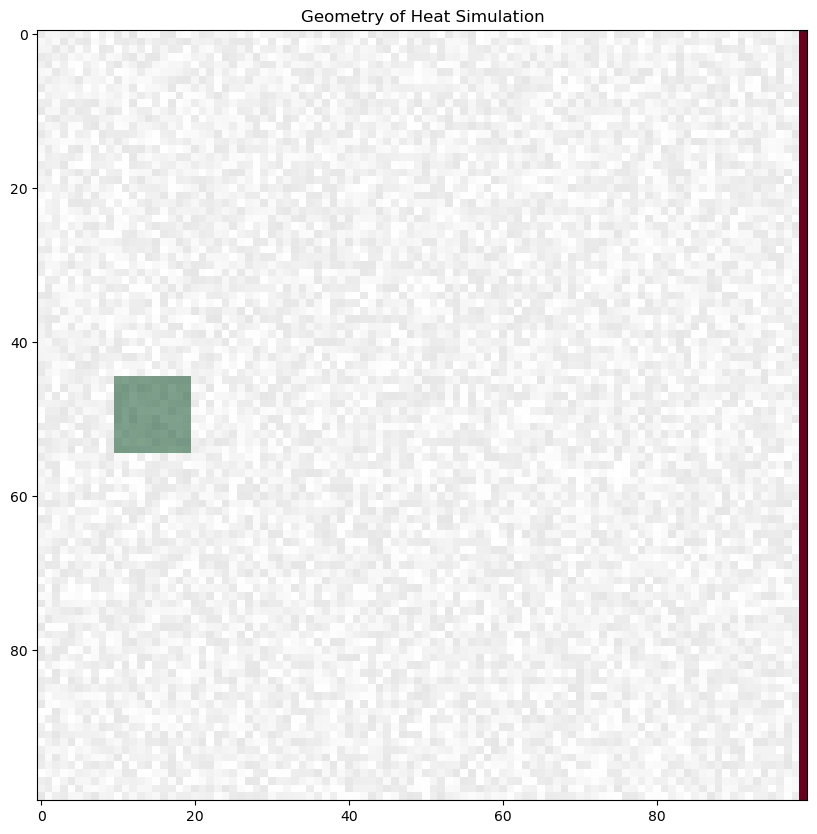

In [212]:
get_alpha = lambda data, top, bottom: (abs(data) - bottom) / (top - bottom)
alpha_A   = get_alpha(A_map.map,   np.max(A_map.map ) or 1, 0)
alpha_T   = get_alpha(T_map.map,   np.max(T_map.map ) or 1, 0)
alpha_Tf  = get_alpha(Tf_map.map,  np.max(Tf_map.map) or 1, 0)
alpha_Ta  = get_alpha(Ta_map.map,  np.max(Ta_map.map) or 1, 0)
alpha_D   = get_alpha(D_map.map,   np.max(D_map.map ) or 1, 0)

plt.figure(figsize=(10, 10))
plt.title("Geometry of Heat Simulation")
plt.imshow(A_map.map,  cmap="Greys",  vmin= 0, vmax=1, alpha=alpha_A * 0.1,  label="A")
plt.imshow(T_map.map,  cmap="PuRd",   vmin= 0, vmax=1, alpha=alpha_T * 0.2,  label="T")
plt.imshow(Tf_map.map, cmap="RdBu",   vmin= 0, vmax=1, alpha=alpha_Tf * 0.5, label="Tf")
plt.imshow(Ta_map.map, cmap="RdBu",   vmin= 0, vmax=1, alpha=alpha_Tf * 0.5, label="Ta")
plt.imshow(D_map.map,  cmap="Greens", vmin= 0, vmax=1, alpha=alpha_D * 0.5,  label="D")

## Define Model

In [213]:
class HeatTimestep(nn.Module):
    """
    The general solution to the heat equation in discrete space and time, regressively defined, is:  
    `T(t+Δt) = T(t) + Δt * ( L @ T(t) / Δx² + T_a )`, where:
    - for a homogenous medium, `L = (W - nD * I)`  
    - for a heterogenous medium, `L = W * (0.5 * Ai + Aj)`  
    """
    def __init__(self, num_dims, Δt, W_sparse, A, I_sparse, T_f, T_a, fm):
        super(HeatTimestep, self).__init__()

        # Assumed for spatial invariance, not used in sim
        self.Δx  = 1

        self.nD  = num_dims
        self.Δt  = Δt
        self.W   = torch.sparse_coo_tensor(W_sparse[0], W_sparse[1], W_sparse[2], dtype=torch.float32, device=DEVICE)    # Ind, Val, Dim
        self.A   = nn.Parameter(torch.tensor(A, dtype=torch.float32, device=DEVICE))                                     # Requires shape=(1, n)
        self.I   = torch.sparse_coo_tensor(I_sparse[0], I_sparse[1], I_sparse[2], dtype=torch.float32, device=DEVICE)
        self.T_a = torch.tensor(T_a, dtype=torch.float32, device=DEVICE) if T_a is not None else None                    # Shape=(n, 1)
        self.T_f = torch.tensor(T_f, dtype=torch.float32, device=DEVICE) if T_f is not None else None                    # Shape=(n, 1)

        # Forcing Mask and Inverted Mask
        self.fm  = torch.tensor(fm, dtype=torch.float32, device=DEVICE)  if (fm is not None and self.T_f is not None) else None
        self.im  = (1 - self.fm) if (self.fm is not None) else None

    def reset_parameters(self):
        """
        Call after backprop
        """
        for prop in "GPL":
            if hasattr(self, prop):
                delattr(self, prop)

    def update_parameters(self):
        """
        Call before each run when A changes
        """
        # G = Heat flux In, P = Heat flux Out, per unit time, per temperature difference
        self.G   = 0.5 * (self.W * self.A.view(-1,1) + self.W * self.A.view(1, -1))     # Build symmetric conductance matrix G where G_ij = (A_i + A_j)/2 if neighbors
        self.P   = self.I * self.G.sum(dim=1).values()                                  # Set magnitude of heat out equal to magnitude of heat in.
        self.L   = -self.P + self.G                                                     # Set heat out = -heat in

    def forward(self, T):
        """
        One timestep
        """
        if not hasattr(self, "L"):
            self.update_parameters()

        # Explicit update
        T_new = T + self.Δt * (self.L @ T) # / (self.Δx*self.Δx)

        # Additive Temperature Sourcing and Sinking
        if self.T_a is not None:
            T_new = T_new + self.Δt * self.T_a

        # Temperature Forcing
        if self.im is not None:
            with torch.no_grad():
                T_new = T_new * self.im + self.T_f
        
        return T_new

## Simulate!

#### Format Data for Model

In [214]:
tF          = 3000

Δt          = 0.025
W_sparse    = sparse_neighbor_matrix(SIM_DIMS)
A           = A_map.flatten_hoz()
I_sparse    = sparse_identity_matrix(SIM_DIMS)
T_a         = Ta_map.flatten_ver()
T_f         = Tf_map.flatten_ver()
T_f_mask    = Tf_mask_map.flatten_ver()

T0          = torch.tensor(T_map.flatten_ver(), dtype=torch.float32, device=DEVICE)

##### Debug

In [215]:
s = {}

s["Δt"]         = Δt
s["W"]          = torch.sparse_coo_tensor(W_sparse[0], W_sparse[1], W_sparse[2], dtype=torch.float32, device=DEVICE)    # Ind, Val, Dim
s["A"]          = nn.Parameter(torch.tensor(A, dtype=torch.float32, device=DEVICE))                                     # Requires shape=(1, n)
s["I"]          = torch.sparse_coo_tensor(I_sparse[0], I_sparse[1], I_sparse[2], dtype=torch.float32, device=DEVICE)
s["T_a"]        = torch.tensor(T_a, dtype=torch.float32, device=DEVICE)                                                 # Shape=(n, 1)
s["T_f"]        = torch.tensor(T_f, dtype=torch.float32, device=DEVICE)                                                 # Shape=(n, 1)
s["T_f_mask"]   = torch.tensor(T_f_mask, dtype=torch.float32, device=DEVICE)                                            # Shape=(n, 1)

### Create Model

In [216]:
step = HeatTimestep(len(SIM_DIMS), Δt, W_sparse, A, I_sparse, T_a, T_f, T_f_mask)

In [217]:
print("The following Parameters are Trainable:")
print("---------------------------------------")
for name, param in step.named_parameters():
    print(name, param.requires_grad)

The following Parameters are Trainable:
---------------------------------------
A True


##### Debug

In [218]:
I = step.I
G = 0.5 * (step.W * step.A.view(-1,1) + step.W * step.A.view(1, -1))

In [219]:
# G = step.G.to_dense().detach().numpy()
# with open("G_dump", "w") as Dump:
#     for row in G:
#         Dump.write(json.dumps(row.tolist()))
#         Dump.write("\n")

In [220]:
# P = step.P.to_dense().detach().numpy()
# with open("P_dump", "w") as Dump:
#     for row in P:
#         Dump.write(json.dumps(row.tolist()))
#         Dump.write("\n")

### Run Model Iteratively from T0 to TF

In [ ]:
def run_sim(step_model, tF, Δt, T0, record_sim_freq = True):
    T_hist = []         # Record This Run's Temp Map

    T = T0              # Set 
    t = 0               # Simulation Time
    tick = time.time()  # Program Start Time
    while t < tF:
        if int(t / Δt) & 0x3FF == 1:
            elapsed   = time.time() - tick
            sim_prog  = t/tF
            sim_fin   = elapsed / sim_prog
            sim_rem   = (sim_fin - elapsed) # * (1 - 0.2 * np.exp(0.5 / (1-sim_prog)))
            print(f"t: {t:8.2f} / {tF:8.2f} ({sim_prog*100:5.2f}%), Sim Time Remaining {sim_rem:8.2f} / {sim_fin:8.2f} sec, T_max = {np.max(T.detach().cpu().numpy()):8.2e}")
            
        T = step_model.forward(T)
        
        if (record_sim_freq):
            T_hist.append(T.detach().cpu().numpy())

        t += Δt

    if record_sim_freq:
        res_df = pd.DataFrame(np.array(T_hist).reshape((len(T_hist), T_hist[0].shape[0])))
        res_df.to_feather("sim_results.feather")

run_sim(step, tF, Δt, T0, record_sim_freq = True)

t:     0.03 /  3000.00 ( 0.00%), Sim Time Remaining   847.10 /  1263.86 sec, T_max = 2.00e-01
t:    25.65 /  3000.00 ( 0.85%), Sim Time Remaining   137.23 /   206.94 sec, T_max = 7.25e+01
t:    51.25 /  3000.00 ( 1.71%), Sim Time Remaining   128.52 /   195.93 sec, T_max = 9.27e+01
t:    76.83 /  3000.00 ( 2.56%), Sim Time Remaining   121.77 /   187.68 sec, T_max = 1.06e+02
t:   102.43 /  3000.00 ( 3.41%), Sim Time Remaining   117.25 /   182.72 sec, T_max = 1.17e+02
t:   128.03 /  3000.00 ( 4.27%), Sim Time Remaining   115.07 /   181.34 sec, T_max = 1.26e+02
t:   153.63 /  3000.00 ( 5.12%), Sim Time Remaining   113.19 /   180.42 sec, T_max = 1.33e+02
t:   179.23 /  3000.00 ( 5.97%), Sim Time Remaining   110.84 /   178.71 sec, T_max = 1.40e+02
t:   204.83 /  3000.00 ( 6.83%), Sim Time Remaining   108.48 /   176.95 sec, T_max = 1.46e+02
t:   230.43 /  3000.00 ( 7.68%), Sim Time Remaining   107.65 /   177.68 sec, T_max = 1.51e+02
t:   256.03 /  3000.00 ( 8.53%), Sim Time Remaining   105.78